In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("/content/foodtimedataset.xlsx")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

First 5 Rows:
     ID Delivery Person ID  Delivery Person Age  Delivery Person Ratings  \
0  4607     INDORES13DEL02                 37.0                      4.9   
1  B379     BANGRES18DEL02                 34.0                      4.5   
2  5D6D     BANGRES19DEL01                 23.0                      4.4   
3  7A6A    COIMBRES13DEL02                 38.0                      4.7   
4  70A2     CHENRES12DEL01                 32.0                      4.6   

   Restaurant Latitude  Restaurant Longitude  Delivery Location Latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery Location Longitude Order Type Vehicle Type  Temperature  Hum

In [3]:
import pandas as pd, numpy as np
df = pd.read_excel("/content/foodtimedataset.xlsx")

df = df.dropna(how="all").copy()
for c in ["Order Type","Vehicle Type","Weather Description","Traffic Level","Delivery Person ID"]:
    df[c] = df[c].str.strip()
df["Vehicle Type"] = df["Vehicle Type"].str.lower()
df["City"] = df["Delivery Person ID"].str.extract(r"^([A-Z]+?)RES")[0]

df = df.drop_duplicates(subset="ID", keep="first")

# invalid values -> NaN
df.loc[df["Delivery Person Ratings"] > 5, "Delivery Person Ratings"] = np.nan
df.loc[df["Delivery Person Age"] < 18, "Delivery Person Age"] = np.nan
df.loc[df["Delivery Location Latitude"] < 1, ["Delivery Location Latitude","Delivery Location Longitude"]] = np.nan

# labeled data for ML
labeled = df.dropna(subset=["Delivery Time","Distance"])
print(df.shape, labeled.shape)
print(labeled.isnull().sum())

(9991, 18) (9027, 18)
ID                             0
Delivery Person ID             0
Delivery Person Age            4
Delivery Person Ratings        3
Restaurant Latitude            0
Restaurant Longitude           0
Delivery Location Latitude     0
Delivery Location Longitude    0
Order Type                     0
Vehicle Type                   0
Temperature                    0
Humidity                       0
Precipitation                  0
Weather Description            0
Traffic Level                  0
Distance                       0
Delivery Time                  0
City                           0
dtype: int64


In [4]:

print(labeled.isnull().sum())


d = labeled.copy()
for c in ["Delivery Person Age", "Delivery Person Ratings", "Temperature", "Humidity", "Precipitation"]:
    d[c] = d[c].fillna(d[c].median())
for c in ["Weather Description", "Traffic Level", "Order Type", "Vehicle Type"]:
    d[c] = d[c].fillna(d[c].mode()[0])

# . Outlier check: speed = Distance / Time
d["speed"] = d["Distance"] / d["Delivery Time"] * 60
print(d["speed"].describe())
print(d["Delivery Time"].quantile([.01, .5, .95, .99]))
print(d[d["Delivery Time"] > 120][["Distance", "Traffic Level", "Delivery Time"]].head(10))

# . Save
d.drop(columns="speed").to_csv("/content/clean_food_delivery.csv", index=False)
print(d.shape)

ID                             0
Delivery Person ID             0
Delivery Person Age            4
Delivery Person Ratings        3
Restaurant Latitude            0
Restaurant Longitude           0
Delivery Location Latitude     0
Delivery Location Longitude    0
Order Type                     0
Vehicle Type                   0
Temperature                    0
Humidity                       0
Precipitation                  0
Weather Description            0
Traffic Level                  0
Distance                       0
Delivery Time                  0
City                           0
dtype: int64
count    9027.000000
mean       21.652862
std         7.052741
min         5.037700
25%        16.793365
50%        21.607535
75%        26.044557
max        85.336562
Name: speed, dtype: float64
0.01     9.600000
0.50    35.983333
0.95    66.383333
0.99    83.169000
Name: Delivery Time, dtype: float64
      Distance Traffic Level  Delivery Time
444      54.27     Very High     140.983333
5

In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

d = pd.read_csv("/content/clean_food_delivery.csv")
d["speed"] = d["Distance"] / d["Delivery Time"] * 60

print("speed > 60:", (d["speed"] > 60).sum(), "| speed < 6:", (d["speed"] < 6).sum())
print(d[d["speed"] > 60][["Distance","Traffic Level","Vehicle Type","Delivery Time","speed"]].head(10))


speed > 60: 1 | speed < 6: 25
      Distance Traffic Level Vehicle Type  Delivery Time      speed
4544      9.79      Very Low   motorcycle       6.883333  85.336562


In [7]:
# 1. impossible row remove
d = d[d["speed"] <= 60].copy()

# 2. slow rows check
slow = d[d["speed"] < 6]
print(slow["Traffic Level"].value_counts())
print(slow[["Distance","Traffic Level","Delivery Time","speed"]].head(8))

Traffic Level
Very Low    14
Low         11
Name: count, dtype: int64
      Distance Traffic Level  Delivery Time     speed
150       2.08      Very Low      21.900000  5.698630
726       2.31           Low      24.400000  5.680328
1755      2.48           Low      25.016667  5.948035
1815      2.23      Very Low      23.016667  5.813179
4322      2.15      Very Low      23.966667  5.382476
4418      2.07      Very Low      21.666667  5.732308
4592      1.60      Very Low      17.266667  5.559846
5053      1.85      Very Low      18.566667  5.978456


In [8]:
d = d.drop(columns="speed")
d.to_csv("/content/clean_food_delivery.csv", index=False)
print(d.shape)

(9026, 18)


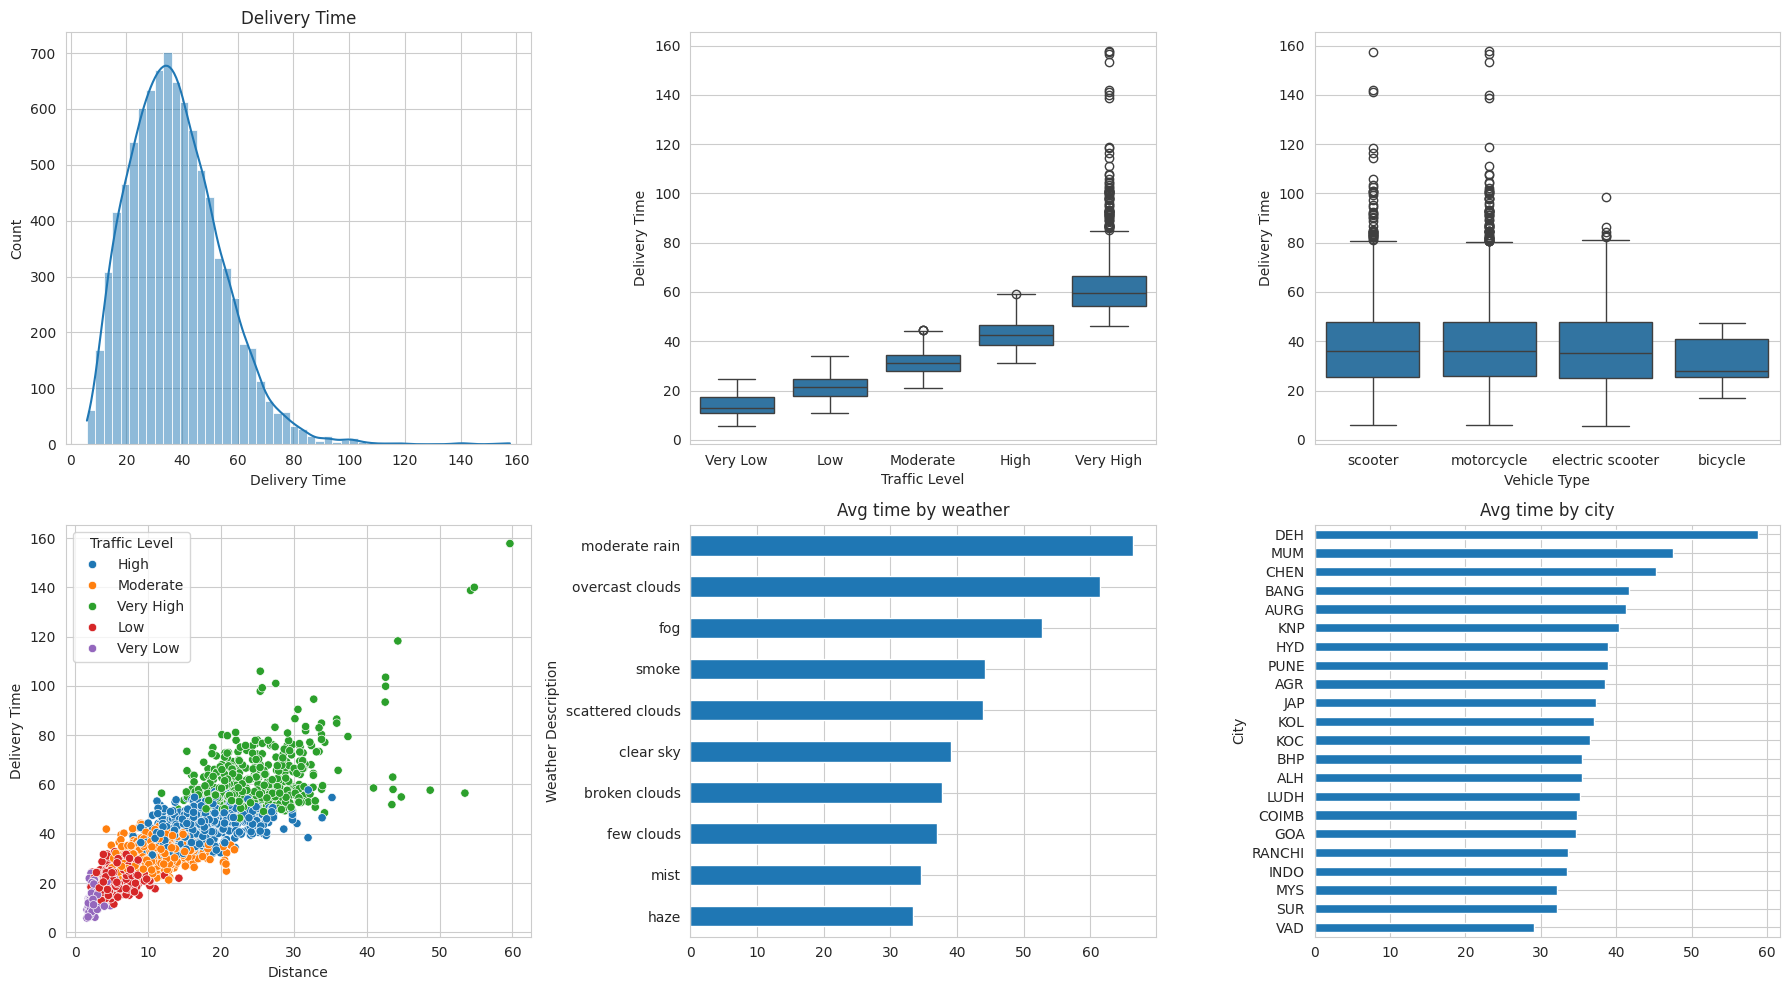

Delivery Time              1.00
Distance                   0.87
Delivery Person Age        0.00
Delivery Person Ratings   -0.10
Temperature                0.05
Humidity                  -0.01
Precipitation              0.01
Name: Delivery Time, dtype: float64


In [9]:
import seaborn as sns, matplotlib.pyplot as plt
sns.set_style("whitegrid")
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(d["Delivery Time"], bins=50, kde=True, ax=ax[0,0]).set_title("Delivery Time")
sns.boxplot(data=d, x="Traffic Level", y="Delivery Time", ax=ax[0,1],
            order=["Very Low","Low","Moderate","High","Very High"])
sns.boxplot(data=d, x="Vehicle Type", y="Delivery Time", ax=ax[0,2])
sns.scatterplot(data=d.sample(2000, random_state=1), x="Distance", y="Delivery Time",
                hue="Traffic Level", ax=ax[1,0])
d.groupby("Weather Description")["Delivery Time"].mean().sort_values().plot.barh(ax=ax[1,1], title="Avg time by weather")
d.groupby("City")["Delivery Time"].mean().sort_values().plot.barh(ax=ax[1,2], title="Avg time by city")

plt.tight_layout(); plt.show()
print(d[["Delivery Time","Distance","Delivery Person Age","Delivery Person Ratings",
         "Temperature","Humidity","Precipitation"]].corr()["Delivery Time"].round(2))

In [10]:
d = pd.read_csv("/content/clean_food_delivery.csv")
d["min_per_km"] = d["Delivery Time"] / d["Distance"]

# weather: sample size + time per km
w = d.groupby("Weather Description").agg(n=("ID","count"),
        avg_time=("Delivery Time","mean"), min_per_km=("min_per_km","mean")).round(2)
print(w.sort_values("min_per_km"))

# city
c = d.groupby("City").agg(n=("ID","count"), avg_dist=("Distance","mean"),
        avg_time=("Delivery Time","mean"), min_per_km=("min_per_km","mean")).round(2)
print(c.sort_values("min_per_km"))

# traffic x vehicle
print(d.pivot_table(index="Traffic Level", columns="Vehicle Type",
                    values="Delivery Time", aggfunc="mean").round(1))

# delay threshold options
for t in [40, 45, 50, 60]:
    print(t, "min ->", round((d["Delivery Time"] > t).mean()*100, 1), "% delayed")

                        n  avg_time  min_per_km
Weather Description                            
fog                    49     52.70        2.28
moderate rain           1     66.45        2.64
clear sky            3207     39.11        2.74
overcast clouds       182     61.42        2.81
scattered clouds      409     43.87        2.87
few clouds             40     36.99        2.97
broken clouds         532     37.73        3.01
haze                 2373     33.38        3.22
mist                 1738     34.59        3.70
smoke                 495     44.13        4.11
          n  avg_dist  avg_time  min_per_km
City                                       
AGR     104     19.62     38.46        2.45
VAD     349     13.06     29.11        2.51
BHP     116     14.75     35.49        2.65
MYS     654     13.91     32.15        2.75
LUDH    136     17.35     35.21        2.76
KNP     140     16.08     40.41        2.86
ALH     114     14.45     35.40        2.89
INDO    668     14.10     33

In [11]:
rain = df[df["Weather Description"] == "light rain"]
print(len(rain))
print(rain[["Distance", "Delivery Time", "Traffic Level"]].isnull().mean())

536
Distance         0.925373
Delivery Time    1.000000
Traffic Level    0.925373
dtype: float64


In [12]:
d = pd.read_csv("/content/clean_food_delivery.csv")

d["traffic_score"] = d["Traffic Level"].map({"Very Low":1,"Low":2,"Moderate":3,"High":4,"Very High":5})
d["dist_x_traffic"] = d["Distance"] * d["traffic_score"]
d["short_trip"] = (d["Distance"] < 3).astype(int)

d["weather_grp"] = d["Weather Description"].replace({
    "few clouds":"clouds","scattered clouds":"clouds","broken clouds":"clouds",
    "overcast clouds":"clouds","fog":"other","moderate rain":"other"})

big = d["City"].value_counts()
big = big[big >= 500].index
d["city_grp"] = np.where(d["City"].isin(big), d["City"], "Other")

d["is_delayed"] = (d["Delivery Time"] > 45).astype(int)

d = d.drop(columns=["ID","Delivery Person ID","Restaurant Latitude","Restaurant Longitude",
                    "Delivery Location Latitude","Delivery Location Longitude"])
d.to_csv("/content/featured_food_delivery.csv", index=False)
print(d.shape, d["is_delayed"].mean().round(3))
print(d.head())

(9026, 18) 0.299
   Delivery Person Age  Delivery Person Ratings Order Type Vehicle Type  \
0                 34.0                      4.5      Snack      scooter   
1                 23.0                      4.4     Drinks   motorcycle   
2                 38.0                      4.7     Buffet   motorcycle   
3                 32.0                      4.6      Snack      scooter   
4                 22.0                      4.8     Buffet   motorcycle   

   Temperature  Humidity  Precipitation Weather Description Traffic Level  \
0        19.50      93.0            0.0                mist     Very High   
1        20.45      91.0            0.0                mist           Low   
2        23.86      78.0            0.0                mist      Moderate   
3        26.55      87.0            0.0                mist          High   
4        21.43      65.0            0.0       broken clouds      Moderate   

   Distance  Delivery Time   City  traffic_score  dist_x_traffic  sho

In [13]:
import sqlite3, pandas as pd
d = pd.read_csv("/content/featured_food_delivery.csv")
con = sqlite3.connect("/content/food.db")
d.to_sql("orders", con, if_exists="replace", index=False)

def q(sql): return pd.read_sql(sql, con)

In [14]:
# 1. KPIs
q("""SELECT COUNT(*) orders, ROUND(AVG("Delivery Time"),1) avg_min,
            ROUND(AVG(is_delayed)*100,1) delay_pct FROM orders""")

# 2. Traffic level vs delay
q("""SELECT "Traffic Level", COUNT(*) orders, ROUND(AVG("Delivery Time"),1) avg_min,
            ROUND(AVG(is_delayed)*100,1) delay_pct
     FROM orders GROUP BY "Traffic Level" ORDER BY traffic_score""")

# 3. City ranking (window function, min 300 orders)
q("""SELECT city, orders, delay_pct, RANK() OVER (ORDER BY delay_pct DESC) AS risk_rank
     FROM (SELECT City city, COUNT(*) orders, ROUND(AVG(is_delayed)*100,1) delay_pct
           FROM orders GROUP BY City HAVING COUNT(*) >= 300)""")

# 4. CTE: distance bucket x traffic
q("""WITH b AS (
       SELECT CASE WHEN Distance < 5 THEN '1) <5 km' WHEN Distance < 15 THEN '2) 5-15 km'
                   WHEN Distance < 25 THEN '3) 15-25 km' ELSE '4) 25+ km' END AS dist_bucket,
              "Traffic Level" traffic, is_delayed FROM orders)
     SELECT dist_bucket, traffic, COUNT(*) orders, ROUND(AVG(is_delayed)*100,1) delay_pct
     FROM b GROUP BY dist_bucket, traffic ORDER BY dist_bucket, delay_pct DESC""")

# 5. Weather group (min 100 orders)
q("""SELECT weather_grp, COUNT(*) orders, ROUND(AVG(is_delayed)*100,1) delay_pct,
            ROUND(AVG("Delivery Time"/Distance),2) min_per_km
     FROM orders GROUP BY weather_grp HAVING COUNT(*) >= 100 ORDER BY delay_pct DESC""")

,weather_grp,orders,delay_pct,min_per_km
0,smoke,495,44.2,4.11
1,clouds,1163,44.2,2.93
2,clear sky,3207,33.8,2.74
3,mist,1738,21.2,3.70
4,haze,2373,19.8,3.22


In [15]:
q("""SELECT weather_grp, ROUND(AVG(Distance),1) avg_km,
            ROUND(AVG(traffic_score),2) avg_traffic,
            ROUND(AVG(is_delayed)*100,1) delay_pct
     FROM orders GROUP BY weather_grp HAVING COUNT(*) >= 100 ORDER BY avg_km DESC""")

,weather_grp,avg_km,avg_traffic,delay_pct
0,clouds,16.7,3.72,44.2
1,clear sky,16.5,3.56,33.8
2,smoke,13.7,3.52,44.2
3,haze,12.3,3.11,19.8
4,mist,11.3,3.01,21.2


In [16]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, roc_auc_score)
from sklearn.inspection import permutation_importance

d = pd.read_csv("/content/featured_food_delivery.csv")
cat = ["Order Type", "Vehicle Type", "weather_grp", "city_grp"]
num = ["Delivery Person Age", "Delivery Person Ratings", "Temperature", "Humidity",
       "Distance", "traffic_score", "dist_x_traffic", "short_trip"]
X = d[cat + num]
pre = ColumnTransformer([("c", OneHotEncoder(handle_unknown="ignore"), cat)],
                        remainder="passthrough")

Xtr, Xte, ytr, yte = train_test_split(X, d["Delivery Time"], test_size=0.2, random_state=42)
regs = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(300, min_samples_leaf=3, n_jobs=-1, random_state=42),
    "HistGB": HistGradientBoostingRegressor(random_state=42),
}
for n, m in regs.items():
    p = Pipeline([("pre", pre), ("m", m)]).fit(Xtr, ytr).predict(Xte)
    mae = mean_absolute_error(yte, p)
    rmse = np.sqrt(mean_squared_error(yte, p))
    r2 = r2_score(yte, p)
    print(n, "MAE", round(mae, 2), "RMSE", round(rmse, 2), "R2", round(r2, 3))





    import joblib
from sklearn.model_selection import train_test_split

tr, te = train_test_split(d, test_size=0.2, random_state=42, stratify=d["is_delayed"])
feats = cat + num

reg = Pipeline([("pre", pre), ("m", HistGradientBoostingRegressor(random_state=42))])
reg.fit(tr[feats], tr["Delivery Time"])
clf = Pipeline([("pre", pre), ("m", HistGradientBoostingClassifier(random_state=42))])
clf.fit(tr[feats], tr["is_delayed"])

out = te.copy()
out["predicted_time"] = reg.predict(te[feats]).round(1)
out["abs_error"] = (out["predicted_time"] - out["Delivery Time"]).abs().round(1)
out["delay_prob"] = clf.predict_proba(te[feats])[:, 1].round(3)
out["risk_band"] = pd.cut(out["delay_prob"], [0, 0.3, 0.7, 1],
                          labels=["Low", "Medium", "High"], include_lowest=True)
out.to_csv("/content/powerbi_predictions.csv", index=False)
joblib.dump(reg, "/content/eta_model.pkl")
joblib.dump(clf, "/content/delay_model.pkl")

print("MAE:", out["abs_error"].mean().round(2))
print(out["risk_band"].value_counts())

print(d.groupby("Order Type").agg(n=("is_delayed", "size"),
      avg_time=("Delivery Time", "mean"), delay_pct=("is_delayed", "mean"),
      avg_km=("Distance", "mean")).round(2))

Linear MAE 3.31 RMSE 4.74 R2 0.918
RandomForest MAE 2.59 RMSE 3.73 R2 0.949
HistGB MAE 2.51 RMSE 3.67 R2 0.951
MAE: 2.54
risk_band
Low       1221
High       482
Medium     103
Name: count, dtype: int64
               n  avg_time  delay_pct  avg_km
Order Type                                   
Buffet      2172     35.43       0.25   14.07
Drinks      2273     43.14       0.42   14.33
Meal        2276     33.91       0.22   14.35
Snack       2305     38.06       0.30   14.35


In [17]:
Xtr, Xte, ytr, yte = train_test_split(
    X, d["is_delayed"], test_size=0.2, random_state=42, stratify=d["is_delayed"])

clfs = {
    "Logistic": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(300, min_samples_leaf=3,
                        class_weight="balanced", n_jobs=-1, random_state=42),
    "HistGB": HistGradientBoostingClassifier(random_state=42),
}
best = None
for n, m in clfs.items():
    pipe = Pipeline([("pre", pre), ("m", m)]).fit(Xtr, ytr)
    pr = pipe.predict_proba(Xte)[:, 1]
    print("\n", n, "ROC-AUC", round(roc_auc_score(yte, pr), 3))
    print(classification_report(yte, (pr > 0.5).astype(int), digits=3))
    best = pipe


 Logistic ROC-AUC 0.989
              precision    recall  f1-score   support

           0      0.979     0.932     0.955      1266
           1      0.857     0.954     0.903       540

    accuracy                          0.939      1806
   macro avg      0.918     0.943     0.929      1806
weighted avg      0.943     0.939     0.939      1806


 RandomForest ROC-AUC 0.989
              precision    recall  f1-score   support

           0      0.970     0.954     0.962      1266
           1      0.897     0.931     0.914       540

    accuracy                          0.947      1806
   macro avg      0.933     0.943     0.938      1806
weighted avg      0.948     0.947     0.948      1806


 HistGB ROC-AUC 0.99
              precision    recall  f1-score   support

           0      0.963     0.971     0.967      1266
           1      0.930     0.913     0.921       540

    accuracy                          0.953      1806
   macro avg      0.947     0.942     0.944      180

In [18]:
r = permutation_importance(best, Xte, yte, n_repeats=5,
                           random_state=42, scoring="roc_auc")
imp = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)
print(imp.round(4))

traffic_score              0.2859
Order Type                 0.0207
dist_x_traffic             0.0105
Distance                   0.0041
city_grp                   0.0037
Humidity                   0.0016
weather_grp                0.0014
Temperature                0.0006
Delivery Person Ratings    0.0002
Delivery Person Age        0.0000
short_trip                 0.0000
Vehicle Type              -0.0001
dtype: float64


In [19]:
print(pd.crosstab(d["Order Type"], d["Traffic Level"], normalize="index").round(2))

Traffic Level  High   Low  Moderate  Very High  Very Low
Order Type                                              
Buffet         0.30  0.19      0.25       0.18      0.08
Drinks         0.30  0.19      0.24       0.21      0.07
Meal           0.32  0.19      0.24       0.19      0.06
Snack          0.29  0.19      0.25       0.20      0.06


In [20]:
from google.colab import files
files.download("/content/powerbi_predictions.csv")
files.download("/content/featured_food_delivery.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import shutil, os
os.makedirs("/content/pack", exist_ok=True)
for f in ["clean_food_delivery.csv", "featured_food_delivery.csv",
          "powerbi_predictions.csv", "eta_model.pkl", "delay_model.pkl"]:
    shutil.copy("/content/" + f, "/content/pack/" + f)
shutil.make_archive("/content/project_files", "zip", "/content/pack")

from google.colab import files
files.download("/content/project_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>